#creating a ipynb file

In [ ]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# load data
(x_train , y_train) , (x_test , y_test) = mnist.load_data()

In [ ]:
# testing shape
print("Training data shape : ",x_train.shape)
print("Testing data shape : ",x_test.shape)

Training data shape :  (60000, 28, 28, 1)
Testing data shape :  (10000, 28, 28, 1)


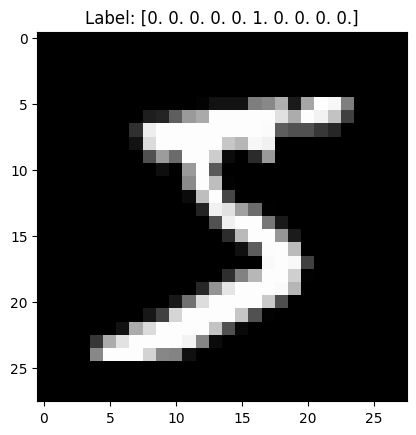

In [ ]:
# First image and its label
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [ ]:
# Normalizing the data
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
# Reshaping the data
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

In [3]:
# One hot en-coding
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

# Conforming shapes
print("x_train shape :",x_train.shape)
print("y_train shape :",y_train.shape)

NameError: name 'to_categorical' is not defined

In [ ]:
# Conforming shapes
print("x_train shape :",x_train.shape)
print("y_train shape :",y_train.shape)

x_train shape : (60000, 28, 28, 1)
y_train shape : (60000, 10, 10, 10)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import MaxPooling2D, Conv2D, Flatten, Dense

In [ ]:
# Building Model
model = Sequential()

model.add(Conv2D(32 , kernel_size=(3,3), activation='relu', input_shape = (28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(128, activation = 'relu' ))
model.add(Dense(10, activation = 'softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compiling the model
model.compile(optimizer='adam' , loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training the model
history = model.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.1)


Epoch 1/5


ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(None, 10, 10), output.shape=(None, 10)

In [ ]:
# Evaluating the model
test_loss, test_accuracy = model.evaluate(x_test,y_test)
print(f"\nTest Accuracy : {test_accuracy * 100:.2f}%")

In [ ]:
# Testing the model
import random

index = random.randint(0, x_test.shape[0] - 1)
image = x_test[index]
true_label = np.argmax(y_test[index])

prediction = model.predict(image.reshape(-1,28,28,1))
predicted_label = np.argmax(prediction)

print("Prediction vector :")
print(prediction[0])
print("prediction label:", np.argmax(prediction))
print("True label:", true_label)

plt.imshow(image.reshape(28,28), cmap = 'gray')
plt.title(f"True: {true_label}, Predicted : {predicted_label}")
plt.axis('off')
plt.show()